# Data Pre-Processing

Import Packages and CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"Visadataset.csv")
# Print shape of dataset
print(df.shape)

(25480, 12)


# Data Cleaning

## Handling Missing values

- Handling Missing values
- Handling Duplicates
- Check data type
- Understand the dataset

#### Check Null Values

In [4]:
# these are the features with nan value
features_with_na = [
    features for features in df.columns if df[features].isnull().sum() >= 1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100,5), '% missing values')

In [6]:
features_with_na

[]

- here are no null values in the dataset

## 3.2 Other Data Cleaning steps

#### Handling Duplicates

In [7]:
df.duplicated().sum()

0

-  No Duplicates in the dataset

##### Remove case_id from the dataset as it cannot used in Model Training

In [8]:
df.drop('case_id', inplace=True, axis=1)

## Feature Engineering

#### Feature Extraction

In [9]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [10]:
# importing date class from datetime module
from datetime import date

# creating the date object of today's date
todays_date = date.today()
current_year = todays_date.year

In [11]:
current_year

2024

#### Subtract current year with year of estab to get company's age

In [12]:
df['company_age'] = current_year-df['yr_of_estab']

In [13]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,17
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,22
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,16
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,127
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,19


In [14]:
df.drop('yr_of_estab', inplace=True, axis=1)

### Type of Features

##### Numeric Features

In [15]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']
print('Number of numerical variables: ', len(numerical_features))

Number of numerical variables:  3


##### Categorical Features

In [16]:
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O'] 
print('Number of categorical variables: ', len(categorical_features))

Number of categorical variables:  8


##### Discrete features

In [17]:
discrete_feature=[feature for feature in numerical_features if len(df[feature].unique())<=25]
print("Discrete Variables Count: {}".format(len(discrete_feature)))

Discrete Variables Count: 0


##### Continuous Features

In [19]:
continuous_feature=[feature for feature in numerical_features if feature not in discrete_feature]
print(f"Number of continuous features: {len(continuous_feature)}")

Number of continuous features: 3


## Split X and Y

- Split Dataframe to X and y
- Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the “Case_Status” column.

In [20]:
x = df.drop('case_status', axis=1)
y = df['case_status']


In [21]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

#### Manual encoding target column

In [22]:
# If the target column has Denied then it is encoded as 0 and Certified then it is encoded as 1
y = y.map({'Denied': 0, 'Certified': 1})

In [23]:
y

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_status, Length: 25480, dtype: int64

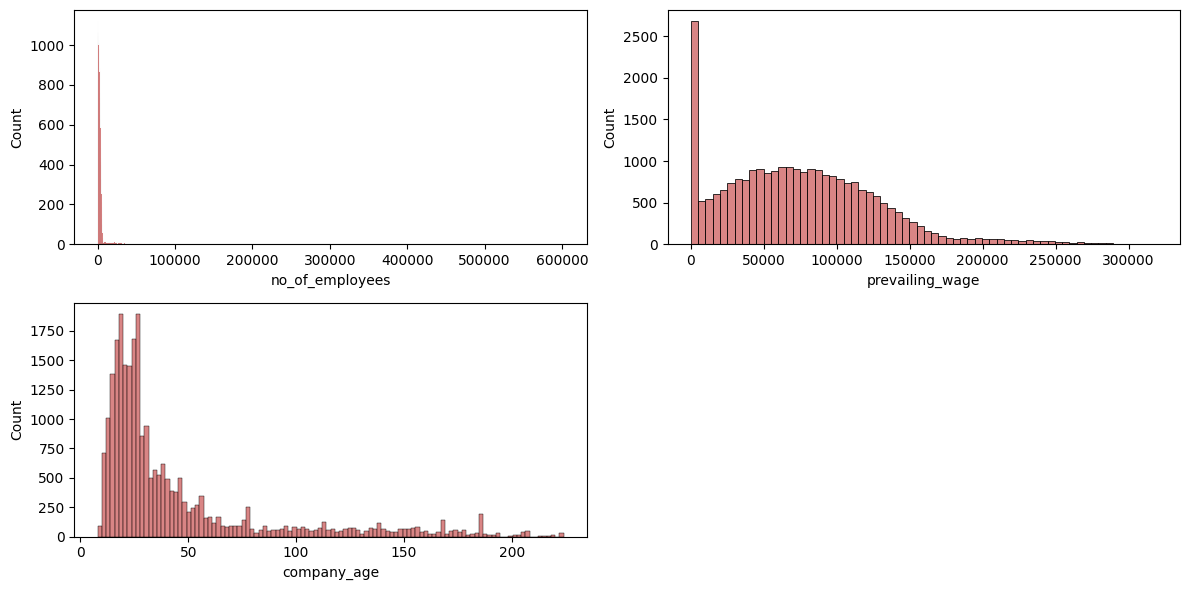

In [24]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(["no_of_employees", "prevailing_wage", "company_age"]):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=x[col], color="indianred")
    plt.xlabel(col)
    plt.tight_layout()

- No of employees and Copmany age column is skewed
- Apply a power transform featurewise to make data more Gaussian-like.


Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

##### Checking Skewness

##### What is Skewness ?

- Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [25]:
# check for skewness in the continuous features
skewness = x[continuous_feature].apply(lambda x: x.skew()).sort_values(ascending=False)
skewness = skewness[abs(skewness) > 0.5]
print(str(skewness.shape[0]) + " skewed numerical features to log transform")

3 skewed numerical features to log transform


In [26]:
x[continuous_feature].skew(axis=0, skipna=True)



no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

- Positiviely Skewed : company_age, no_of_employees.
- We can handle outliers and then check the skewness.

### Apply Power Transformer to Check if it can reduces the outliers

In [27]:
# apply power transform to the skewed features
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ["company_age", "no_of_employees", "prevailing_wage"]
x_copy = pt.fit_transform(x[transform_features])

In [28]:
x_copy = pd.DataFrame(x_copy, columns=transform_features)

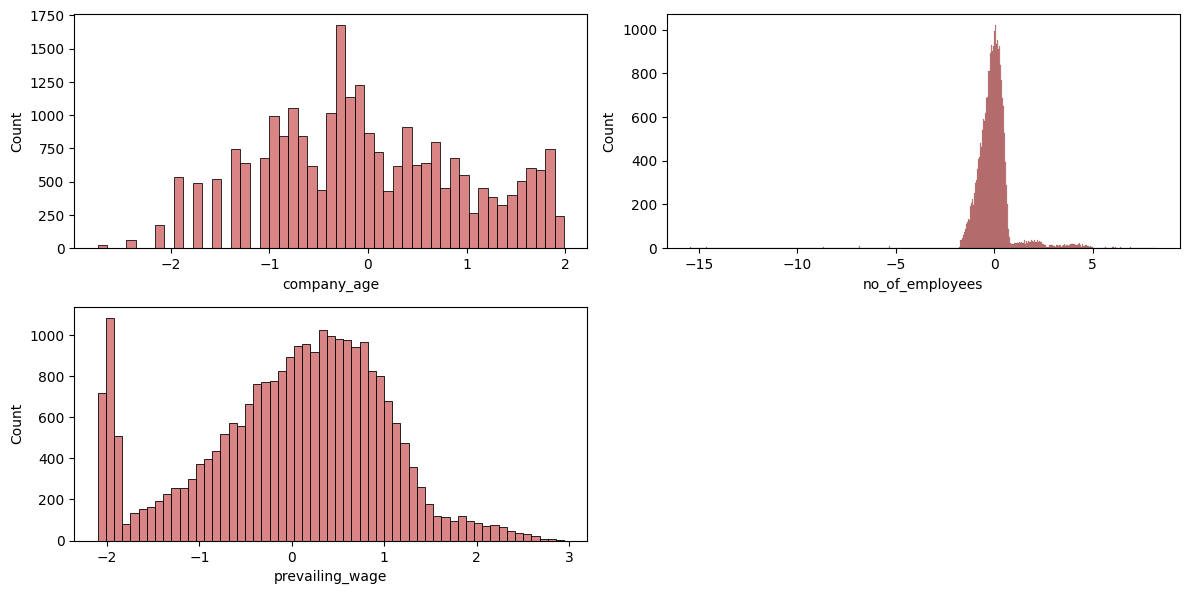

In [29]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(transform_features):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=x_copy[col], color="indianred")
    plt.xlabel(col)
    plt.tight_layout()

In [31]:
x_copy.skew(axis=0, skipna=True)

company_age        0.103264
no_of_employees    0.399339
prevailing_wage   -0.338620
dtype: float64

- Here Yeo-Johnson is used and it supports both positive or negative data for transformation.
- So Power Transformer with yeo-johnson can be used.

In [83]:

# Remove 'case_status' from categorical_features if it exists
categorical_features = [feature for feature in categorical_features if feature != 'case_status']

for feature in categorical_features:
    print(f'The feature is {feature} and number of categories are {len(x[feature].unique())}')

 #   print('The feature is {} and number of categories are {}'.format(feature, len(x[feature].unique())))

The feature is continent and number of categories are 6
The feature is education_of_employee and number of categories are 4
The feature is has_job_experience and number of categories are 2
The feature is requires_job_training and number of categories are 2
The feature is region_of_employment and number of categories are 5
The feature is unit_of_wage and number of categories are 4
The feature is full_time_position and number of categories are 2


### Feature Encoding and Scaling
##### One Hot Encoding for Columns which had lesser unique values and not ordinal

- One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

##### Ordinal Encoding for Columns which has many unique categories

- Ordinal encoding is used here as label encoder is supported for column transformer.
- Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

#### Standard Scaler

- Standardize features by removing the mean and scaling to unit variance.

#### Power Transformer

- Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

#### Selecting number features for preprocessing

In [37]:
numerical_features = list(x.select_dtypes(include=[np.number]).columns)

In [38]:
numerical_features

['no_of_employees', 'prevailing_wage', 'company_age']

#### Preprocessing using Column Transformer

In [69]:
# Create Column Transformer with 3 types of transformers
# Define column groups
ordinal_features = ["has_job_experience", "requires_job_training",
                    "full_time_position", "education_of_employee"]
one_hot_features = ["continent", "unit_of_wage", "region_of_employment"]
numerical_features = ["company_age", "no_of_employees", "prevailing_wage"]

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler, OrdinalEncoder,PowerTransformer
from sklearn.pipeline import Pipeline


In [71]:
# Define transformers
numerical_transformer = StandardScaler()
one_hot_transformer = OneHotEncoder(handle_unknown='ignore')
ordinal_transformer = OrdinalEncoder()

In [72]:
# Define a PowerTransformer for numerical transformation with specific columns
transform_pipeline = Pipeline(steps=[
    ("power_transform", PowerTransformer(method='yeo-johnson'))
])

# Combine all transformations into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical_scaler', numerical_transformer, numerical_features),
        ('one_hot_encoder', one_hot_transformer, one_hot_features),
        ('ordinal_encoder', ordinal_transformer, ordinal_features),
        ('power_transformer', transform_pipeline, numerical_features)
    ]
)

In [73]:
# Apply the preprocessor to your dataset
x_processed = preprocessor.fit_transform(x)

In [74]:
x_processed

array([[-0.65122993,  0.38666657, -1.39853722, ..., -0.95216153,
         1.51729976, -1.93915141],
       [-0.53321103, -0.14228155,  0.1698353 , ..., -0.46294171,
         0.03091211,  0.34503309],
       [-0.6748337 ,  1.69498375,  0.91907852, ..., -1.07581951,
         2.88507606,  0.91555926],
       ...,
       [ 1.63833662, -0.19871259,  1.36027953, ...,  1.54744459,
        -0.41388512,  1.21170443],
       [ 2.18122353, -0.16387483,  0.22150859, ...,  1.68383399,
        -0.11194883,  0.38794165],
       [ 0.45814768, -0.10805575, -0.06776315, ...,  1.0229662 ,
         0.21874168,  0.13879466]])

## Classification

In [75]:
from imblearn.combine import SMOTETomek, SMOTEENN

In [76]:
# Resampling the minority class using SMOTEENN. The strategy is to combine over-sampling of the minority class with under-sampling of the majority class. It can be changed as per the requirement.
smote_enn = SMOTEENN(random_state=42, sampling_strategy="minority")
# Fit the model to generate the data.
x_resampled, y_resampled = smote_enn.fit_resample(x_processed, y)


## Train Test Split

- The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

- It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms.

In [77]:
from sklearn.model_selection import train_test_split   
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((13717, 25), (3430, 25), (13717,), (3430,))

In [80]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score,  roc_auc_score, roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [58]:

def evaluate_classifier(true, predicted):
    accuracy = accuracy_score(true, predicted) # Calculate the accuracy of the model
    precision = precision_score(true, predicted) # Calculate the precision of the model
    recall = recall_score(true, predicted) # Calculate the recall of the model
    f1 = f1_score(true, predicted) # Calculate the F1 score of the model
    roc_auc = roc_auc_score(true, predicted) # Calculate the ROC AUC score of the model
    return accuracy, precision, recall, f1, roc_auc

In [81]:
# Create a dictionary of classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(verbose=False),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [65]:
x_train

array([[-0.60402237, -0.23556105,  0.21558507, ..., -0.73395282,
        -1.01979056,  0.38305504],
       [-0.45728708, -0.18923889, -1.16257889, ..., -0.23479032,
        -0.35165252, -1.24416976],
       [-0.43879592, -0.22642543,  1.03313836, ..., -0.17611789,
        -0.80341776,  0.99443844],
       ...,
       [-0.54047714, -0.15709722,  0.99734804, ..., -0.49897394,
        -0.0671167 ,  0.96889786],
       [-0.46239969, -0.19574023, -1.4001147 , ..., -0.24141887,
        -0.38288515, -1.95256278],
       [-0.27356946, -0.07090131, -0.53305509, ...,  0.19520895,
         0.38778636, -0.32179381]])

In [84]:
# Define evaluate_models function
def evaluate_models(x, y, models):
    """
    Evaluate models on a training and test set, print metrics, and return a summary report.
    """
    # Lists to store model metrics
    models_list = []
    accuracy_list = []
    auc_list = []
    f1_list = []
    precision_list = []
    recall_list = []

    for i in range(len(models)):
        model = list(models.values())[i]
        model_name = list(models.keys())[i]
        model.fit(x_train, y_train)

        # Predictions
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        # Training set performance
        model_train_accuracy, model_train_precision, model_train_recall, model_train_f1, model_train_roc_auc = evaluate_classifier(
            y_train, y_train_pred)

        # Test set performance
        model_test_accuracy, model_test_precision, model_test_recall, model_test_f1, model_test_roc_auc = evaluate_classifier(
            y_test, y_test_pred)

        # Append test set results to lists
        models_list.append(model_name)
        accuracy_list.append(model_test_accuracy)
        auc_list.append(model_test_roc_auc)
        f1_list.append(model_test_f1)
        precision_list.append(model_test_precision)
        recall_list.append(model_test_recall)

        # Assume evaluate_classifier function returns metrics for both training and test sets

        # Print Training Performance with four decimal places
        print(f"Model: {model_name}")
        print("Training Performance:")
        print(f"- Accuracy: {model_train_accuracy:.4f}")
        print(f"- Precision: {model_train_precision:.4f}")
        print(f"- Recall: {model_train_recall:.4f}")
        print(f"- F1 Score: {model_train_f1:.4f}")
        print(f"- ROC AUC: {model_train_roc_auc:.4f}")

        print("-----------------------------------")

        # Print Test Performance with four decimal places
        print("Test Performance:")
        print(f"- Accuracy: {model_test_accuracy:.4f}")
        print(f"- Precision: {model_test_precision:.4f}")
        print(f"- Recall: {model_test_recall:.4f}")
        print(f"- F1 Score: {model_test_f1:.4f}")
        print(f"- ROC AUC: {model_test_roc_auc:.4f}")
        print("="*35 + "\n")
    
    # Create summary DataFrame for all models
    report = pd.DataFrame({
        "Model Name": models_list,
        "Accuracy": accuracy_list,
        "ROC AUC": auc_list,
        "F1 Score": f1_list,
        "Precision": precision_list,
        "Recall": recall_list
    }).sort_values(by="Accuracy", ascending=False)

    return report


# Call the function to print and get the report
report = evaluate_models(x=x_resampled, y=y_resampled, models=models)
print(report)

Model: Logistic Regression
Training Performance:
- Accuracy: 0.7404
- Precision: 0.7075
- Recall: 0.7332
- F1 Score: 0.7201
- ROC AUC: 0.7398
-----------------------------------
Test Performance:
- Accuracy: 0.7286
- Precision: 0.6935
- Recall: 0.7327
- F1 Score: 0.7126
- ROC AUC: 0.7289

Model: Random Forest
Training Performance:
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
- ROC AUC: 1.0000
-----------------------------------
Test Performance:
- Accuracy: 0.9446
- Precision: 0.9397
- Recall: 0.9397
- F1 Score: 0.9397
- ROC AUC: 0.9442

Model: AdaBoost
Training Performance:
- Accuracy: 0.8595
- Precision: 0.8458
- Recall: 0.8457
- F1 Score: 0.8458
- ROC AUC: 0.8584
-----------------------------------
Test Performance:
- Accuracy: 0.8557
- Precision: 0.8479
- Recall: 0.8356
- F1 Score: 0.8417
- ROC AUC: 0.8542

Model: Gradient Boosting
Training Performance:
- Accuracy: 0.8874
- Precision: 0.8805
- Recall: 0.8712
- F1 Score: 0.8758
- ROC AUC: 0.8861
-------

#### Here we can use Random Forest for Hyper Parameter Tuning

#### Define the parameter distribution for Random forest

In [85]:
# Initialize few parameters for the Hyperparameter tuning
xgboost_params = {
    "max_depth": range(3, 10, 2),
    "min_child_weight": range(1, 6, 2)
}
random_forest_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ["sqrt", "log2", None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "weights": ["uniform", "distance"],
    "n_neighbors": [3, 4,  5, 7, 9]
}



In [86]:
# model list for hyperparameter tuning
randomCV_models = [
    ("Random Forest", RandomForestClassifier(), random_forest_params),
    ("XGBoost", XGBClassifier(), xgboost_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

### Create a function for model training and report which can be used in hyperparameter tuning loop

In [100]:
# Define a function to perform hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


def hyperparameter_tuning(x, y, randomCV_models):
    """
    Perform hyperparameter tuning on models using RandomizedSearchCV.
    Returns a dictionary with the best parameters for each model.
    """
    model_params = {}
    for name, model, params in randomCV_models:
        random = RandomizedSearchCV(
            estimator=model,
            param_distributions=params,
            n_iter=100,
            cv=3,
            n_jobs=-1,
            verbose=2
        )
        random.fit(x_resampled, y_resampled)
        model_params[name] = random.best_params_

    return model_params


# Call the function and store the best parameters in a dictionary
best_params_dict = hyperparameter_tuning(
    x_resampled, y_resampled, randomCV_models)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits


In [101]:
best_params_dict

{'Random Forest': {'n_estimators': 200,
  'max_features': 'sqrt',
  'max_depth': None},
 'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

### Retraining the Model with the Parameters

In [103]:

from sklearn.metrics import roc_auc_score, roc_curve


# Retraining the Model with the Parameters
best_models = {
    "Random Forest": RandomForestClassifier(**best_params_dict["Random Forest"]),
    "XGBoost": XGBClassifier(**best_params_dict["XGBoost"], n_jobs=-1),
    "KNN": KNeighborsClassifier(**best_params_dict["KNN"])
}

# Evaluate the models with the best parameters
tuned_report = evaluate_models(x=x_resampled, y=y_resampled, models=best_models)

Model: Random Forest
Training Performance:
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
- ROC AUC: 1.0000
-----------------------------------
Test Performance:
- Accuracy: 0.9504
- Precision: 0.9477
- Recall: 0.9441
- F1 Score: 0.9459
- ROC AUC: 0.9500

Model: XGBoost
Training Performance:
- Accuracy: 0.9993
- Precision: 0.9995
- Recall: 0.9989
- F1 Score: 0.9992
- ROC AUC: 0.9992
-----------------------------------
Test Performance:
- Accuracy: 0.9394
- Precision: 0.9362
- Recall: 0.9314
- F1 Score: 0.9338
- ROC AUC: 0.9388

Model: KNN
Training Performance:
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
- ROC AUC: 1.0000
-----------------------------------
Test Performance:
- Accuracy: 0.9641
- Precision: 0.9727
- Recall: 0.9486
- F1 Score: 0.9605
- ROC AUC: 0.9630



In [104]:
tuned_report

,Model Name,Accuracy,ROC AUC,F1 Score,Precision,Recall
2,KNN,0.964140,0.962965,0.960463,0.972656,0.948571
0,Random Forest,0.950437,0.949961,0.945929,0.947737,0.944127
1,XGBoost,0.939359,0.938760,0.933800,0.936184,0.931429


In [108]:

# Train the final model with the best parameters
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


# Train the final model with the best parameters
best_model = KNeighborsClassifier(**best_params_dict["KNN"])
best_model = best_model.fit(x_train, y_train)

# Make predictions
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]  # Probabilities for ROC AUC

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
# Adjust 'binary' to 'macro' for multiclass
precision = precision_score(y_test, y_pred, average='binary')
# Adjust 'binary' to 'macro' for multiclass
recall = recall_score(y_test, y_pred, average='binary')
# Adjust 'binary' to 'macro' for multiclass
f1 = f1_score(y_test, y_pred, average='binary')
roc_auc = roc_auc_score(y_test, y_prob)
class_report = classification_report(
    y_test, y_pred)          # Renamed to avoid conflict
conf_matrix = confusion_matrix(y_test, y_pred)

# Print all metrics
print("FINAL MODEL: 'KNN'")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(class_report)
print("\nConfusion Matrix:")
print(conf_matrix)

FINAL MODEL: 'KNN'
Accuracy: 0.9641
Precision: 0.9727
Recall: 0.9486
F1 Score: 0.9605
ROC AUC Score: 0.9866

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1855
           1       0.97      0.95      0.96      1575

    accuracy                           0.96      3430
   macro avg       0.96      0.96      0.96      3430
weighted avg       0.96      0.96      0.96      3430


Confusion Matrix:
[[1813   42]
 [  81 1494]]


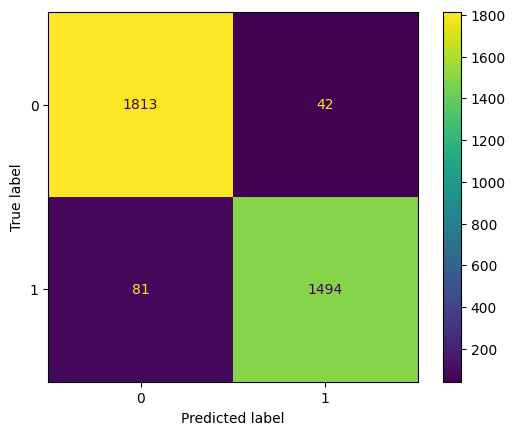

In [110]:
ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)